<a href="https://colab.research.google.com/github/Data-Creater-Atlas/Data-Atlas/blob/Seongjong/mission4_1_3_input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title 1. 드라이브 마운트 및 라이브러리 설치
from google.colab import drive
import os, glob, random, re, math, warnings, json, time, io, datetime
from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

# --- 구글 드라이브 연결 ---
drive.mount('/content/drive')

# --- 필요 라이브러리 설치 ---
!pip -q install -U tifffile imagecodecs

# --- GPU 및 AMP(혼합 정밀도) 설정 ---
print("TF Version:", tf.__version__)
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("AMP Policy:", tf.keras.mixed_precision.global_policy())
except Exception as e:
    print(f"AMP 설정 실패: {e}")

print("\n✅ 환경 설정이 완료되었습니다.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF Version: 2.19.0
AMP Policy: <DTypePolicy "mixed_float16">

✅ 환경 설정이 완료되었습니다.


In [2]:
#@title 2. 데이터셋 경로 설정
from pathlib import Path

# --- 본인의 드라이브 경로 ---
ROOT = Path("/content/drive/MyDrive/Data Camp/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터")

# --- 미션 4-1 (SN10) 데이터 폴더 경로 ---
TR_IMG_DIR    = ROOT / "Training/01.원천데이터/TS_SN10_SN10"
TR_LABEL_DIR  = ROOT / "Training/02.라벨링데이터/TL_SN10"
VAL_IMG_DIR   = ROOT / "Validation/01.원천데이터/VS_SN10_SN10"
VAL_LABEL_DIR = ROOT / "Validation/02.라벨링데이터/VL_SN10"

print("✅ 데이터 경로가 설정되었습니다.")
print(f"학습 이미지 경로: {TR_IMG_DIR}")

✅ 데이터 경로가 설정되었습니다.
학습 이미지 경로: /content/drive/MyDrive/Data Camp/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_SN10_SN10


In [3]:
#@title 3. 데이터 파일 확인 (이미지 & 라벨 페어링)
def list_pairs(img_dir: Path, lbl_dir: Path):
    imgs = sorted([p for p in Path(img_dir).glob("*.tif")])
    lbls = []
    miss = []
    for p in imgs:
        q = Path(lbl_dir) / (p.stem + ".tif")
        if not q.exists():
            miss.append(p.stem)
        else:
            lbls.append(q)
    if miss:
        print(f"[경고] 라벨 파일 누락 {len(miss)}개: {miss[:3]}")
        imgs = [p for p in imgs if (lbl_dir / f"{p.stem}.tif").exists()]

    if len(imgs) == 0:
        print(f"❌ [오류] {img_dir} 경로에서 .tif 파일을 찾지 못했습니다. 2번 셀의 경로를 다시 확인해주세요.")

    return imgs, lbls

tr_imgs, tr_lbls = list_pairs(TR_IMG_DIR, TR_LABEL_DIR)
va_imgs, va_lbls = list_pairs(VAL_IMG_DIR, VAL_LABEL_DIR)
print(f"✅ 파일 페어링 완료: [학습셋] {len(tr_imgs)}쌍, [검증셋] {len(va_imgs)}쌍")

✅ 파일 페어링 완료: [학습셋] 8000쌍, [검증셋] 1000쌍


In [4]:
#@title 4. 데이터 로더 및 증강(Augmentation) 함수 정의
CLIP_MAX = 10000.0
IMG_SIZE    = (256, 256)
NUM_CLASSES = 2
BATCH_SIZE  = 8  # ⚠️ TransUNet은 무거우므로 배치 사이즈를 8 또는 16으로 설정합니다.
AUTOTUNE    = tf.data.AUTOTUNE
SEED        = 42
EXPECTED_CHANNELS = 5 # 5채널 (RGB+NO2+AIR)

def decode_img_from_bytes_np(b):
    try:
        arr = tiff.imread(io.BytesIO(memoryview(b).tobytes()))
        if arr.ndim == 3 and arr.shape[0] <= 20: arr = np.moveaxis(arr, 0, -1)
        if arr.ndim == 2: arr = arr[..., np.newaxis]
        arr = arr.astype(np.float32, copy=False); arr = np.clip(arr, 0, CLIP_MAX) / CLIP_MAX
        return np.nan_to_num(arr, nan=0.0)
    except: return np.zeros((512, 512, EXPECTED_CHANNELS), dtype=np.float32)

def decode_mask_from_bytes_np(b):
    try:
        m = tiff.imread(io.BytesIO(memoryview(b).tobytes()))
        if m.ndim == 3: m = m[..., 0]
        if not np.issubdtype(m.dtype, np.integer): m = m.astype(np.int64, copy=False)
        m = (m == 10).astype(np.int32, copy=False) # 10 = 오염원(1), 그 외 = 배경(0)
        return m
    except: return np.zeros((512, 512), dtype=np.int32)

def load_pair(img_path, lbl_path):
    img = tf.numpy_function(decode_img_from_bytes_np, [tf.io.read_file(img_path)], tf.float32)
    msk = tf.numpy_function(decode_mask_from_bytes_np, [tf.io.read_file(lbl_path)], tf.int32)
    img.set_shape([None, None, None]); msk.set_shape([None, None])
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    msk = tf.image.resize(msk[..., None], IMG_SIZE, method="nearest")
    return img, tf.cast(msk, tf.float32)

def strong_aug(img, m):
    if tf.random.uniform([]) < 0.5: img, m = tf.image.flip_left_right(img), tf.image.flip_left_right(m)
    if tf.random.uniform([]) < 0.5: img, m = tf.image.flip_up_down(img), tf.image.flip_up_down(m)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32); img, m = tf.image.rot90(img, k), tf.image.rot90(m, k)
    if tf.random.uniform([]) < 0.3: img = tf.image.random_brightness(img, 0.08)
    if tf.random.uniform([]) < 0.3: img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, m

print("✅ 데이터 로더 및 증강 함수가 정의되었습니다.")

✅ 데이터 로더 및 증강 함수가 정의되었습니다.


In [5]:
#@title 5. TensorFlow 데이터셋 생성
def make_ds(imgs, lbls, train=True, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(([str(p) for p in imgs], [str(p) for p in lbls]))
    if train:
        ds = ds.shuffle(len(imgs), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)
    if train:
        ds = ds.map(strong_aug, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(tr_imgs, tr_lbls, train=True)
valid_ds = make_ds(va_imgs, va_lbls, train=False)

print("✅ 학습 및 검증 데이터셋이 생성되었습니다.")

✅ 학습 및 검증 데이터셋이 생성되었습니다.


In [6]:
#@title 6. Modified TransUNet + Cross-Attention 모델 정의
import tensorflow as tf
from tensorflow.keras import layers, models

def conv_block(x, f, drop=0.0):
    x = layers.Conv2D(f, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    if drop > 0: x = layers.SpatialDropout2D(drop)(x)
    return x

def enc(x, f, drop=0.0):
    c = conv_block(x, f, drop)
    p = layers.MaxPool2D(2)(c)
    return c, p

def dec(x, skip, f):
    x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, f)

# --- 2. 트랜스포머(Transformer) 관련 블록 ---
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.projection = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="VALID")
        self.flatten = layers.Reshape(target_shape=(-1, embed_dim))
    def call(self, images):
        patches = self.projection(images); patches = self.flatten(patches); return patches

def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    attn_input = x
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout)(attn_input, attn_input)
    attn_output = layers.Add()([attn_input, attn_output])
    attn_output = layers.LayerNormalization(epsilon=1e-6)(attn_output)

    ffn_input = attn_output
    ffn_output = layers.Dense(ff_dim, activation="relu")(ffn_input)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Add()([ffn_input, ffn_output])
    ffn_output = layers.LayerNormalization(epsilon=1e-6)(ffn_output)
    return ffn_output

# --- 3. Cross-Attention 블록 ---
def cross_attention_block(decoder_feature, encoder_feature, embed_dim, num_heads):
    h, w, c = decoder_feature.shape[1:]
    decoder_query = layers.Reshape((h * w, c))(decoder_feature)
    encoder_kv = encoder_feature

    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(
        query=decoder_query, value=encoder_kv, key=encoder_kv
    )

    attn_output = layers.Reshape((h, w, c))(attn_output)
    fused_feature = layers.Add()([decoder_feature, attn_output])
    return layers.LayerNormalization(epsilon=1e-6)(fused_feature)

# --- 4. 모델 조립 ---
def build_transunet_from_ds(train_ds, img_size=IMG_SIZE, base=64,
                            patch_size_cnn_out=2, embed_dim=768,
                            num_heads=12, ff_dim=3072, num_transformer_layers=12):
    try:
        sample_x, _ = next(iter(train_ds))
        C = int(sample_x.shape[-1])
        if C is None or C <= 0: C = 5
        print(f"✅ [모델 입력 채널] C={C} (자동 감지됨)")
    except Exception as e:
        print(f"샘플 읽기 실패: {e}, 기본값 C=5 사용"); C = 5

    H, W = img_size
    inp = layers.Input((H, W, C))

    # --- [A] CNN Encoder ---
    s1, p1 = enc(inp,  base,     drop=0.10)
    s2, p2 = enc(p1,   base*2,   drop=0.15)
    s3, p3 = enc(p2,   base*4,   drop=0.20)

    # --- [B] Transformer Encoder (Bottleneck) ---
    patches = PatchEmbedding(patch_size=patch_size_cnn_out, embed_dim=embed_dim)(p3)

    transformer_features = patches
    for _ in range(num_transformer_layers):
        transformer_features = transformer_block(transformer_features, embed_dim, num_heads, ff_dim)

    bottleneck_dim = img_size[0] // (2**3 * patch_size_cnn_out)
    bottleneck_shape = (bottleneck_dim, bottleneck_dim, embed_dim)
    bott = layers.Reshape(bottleneck_shape)(transformer_features)

    bott_upscaled = layers.Conv2DTranspose(base*4, 2, strides=2, padding="same")(bott)

    # --- [C] Decoder with Cross-Attention ---
    s3_fused = cross_attention_block(s3, transformer_features, embed_dim=embed_dim, num_heads=num_heads)

    d2 = dec(bott_upscaled, s3_fused, base*4)
    d3 = dec(d2, s2, base*2)
    d4 = dec(d3, s1, base)

    out = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32")(d4)

    model = models.Model(inp, out)
    return model

# --- 5. 모델 생성 ---
model = build_transunet_from_ds(train_ds, img_size=IMG_SIZE, base=64)
model.summary()

✅ [모델 입력 채널] C=4 (자동 감지됨)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 256, 256,  │          0 │ re_lu_1[0][0]     │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 128, 128,  │          0 │ re_lu_3[0][0]     │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ spatial_dropout2

 Total params: 421,165,313 (1.57 GB)

 Trainable params: 421,161,729 (1.57 GB)

 Non-trainable params: 3,584 (14.00 KB)

In [7]:
#@title 7. 손실 함수, 평가지표(mIoU), 옵티마이저 설정
def dice_loss(y_true, y_pred, eps=1e-6):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    return 1.0 - (2.0 * inter + eps) / (denom + eps)

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.backend.binary_crossentropy(y_true, y_pred), axis=[1, 2])
    return bce + dice_loss(y_true, y_pred)

# 미션 평가지표인 mIoU 설정
class MeanIoU(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        return super().update_state(y_true > 0.5, y_pred > 0.5, sample_weight)

steps_per_epoch = math.ceil(len(tr_imgs) / BATCH_SIZE)
schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-4, first_decay_steps=steps_per_epoch * 10,
    t_mul=2.0, m_mul=0.8, alpha=1e-6
)
opt = tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=1e-4)

# 모델 컴파일
model.compile(optimizer=opt, loss=bce_dice_loss, metrics=[MeanIoU(num_classes=NUM_CLASSES)])
print("✅ 모델 컴파일이 완료되었습니다.")

✅ 모델 컴파일이 완료되었습니다.


In [8]:
#@title 8. 콜백 설정 및 모델 학습
# 모델 체크포인트 저장 경로
CKPT_PATH = Path(f"/content/drive/MyDrive/Data Camp/transunet_mission4_best.keras")
CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

# 학습 진행 상황을 알려주는 콜백
class ProgressLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None): self.epoch_start_time = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start_time
        print(f"\n[Epoch {epoch+1} 완료] ⏱ {elapsed//60:.0f}분 {elapsed%60:.0f}초", end="")
        if logs: print(f" | loss: {logs.get('loss'):.4f} | val_loss: {logs.get('val_loss'):.4f} | val_mean_io_u: {logs.get('val_mean_io_u'):.4f}")

cbs = [
    ProgressLogger(),
    tf.keras.callbacks.EarlyStopping(monitor="val_mean_io_u", mode="max", patience=15, verbose=1), # 15 에포크 동안 성능 향상 없으면 조기 종료
    tf.keras.callbacks.ModelCheckpoint(CKPT_PATH, monitor="val_mean_io_u", mode="max", save_best_only=True, verbose=0)
]

# 모델 학습 실행 (Epochs=120)
history = model.fit(
    train_ds,
    epochs=120,
    validation_data=valid_ds,
    callbacks=cbs
)
print(f"\n✅ 학습 완료! 최적 모델이 {CKPT_PATH}에 저장되었습니다.")

Epoch 1/120
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8636 - mean_io_u: 0.6524
[Epoch 1 완료] ⏱ 5분 15초 | loss: 0.7161 | val_loss: 0.6975 | val_mean_io_u: 0.6880
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 363s 181ms/step - loss: 0.8635 - mean_io_u: 0.6525 - val_loss: 0.6975 - val_mean_io_u: 0.6880
Epoch 2/120
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 0.5664 - mean_io_u: 0.7466
[Epoch 2 완료] ⏱ 5분 42초 | loss: 0.5467 | val_loss: 0.7448 | val_mean_io_u: 0.6494
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 342s 341ms/step - loss: 0.5663 - mean_io_u: 0.7466 - val_loss: 0.7448 - val_mean_io_u: 0.6494
Epoch 3/120
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.5015 - mean_io_u: 0.7682
[Epoch 3 완료] ⏱ 1분 55초 | loss: 0.4953 | val_loss: 0.6677 | val_mean_io_u: 0.6979
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 162s 162ms/step - loss: 0.5015 - mean_io_u: 0.7682 - val_loss: 0.6677 - val_mean_io_u: 0.6979
Epoch 4/120
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.4710 - mean_io_u: 0.7809
[Epoch 4 완료] ⏱ 5분

125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.2984 - mean_io_u: 0.8528

--- 최종 성능 지표 (mIoU) ---
  - loss        : 0.2927
  - mean_io_u   : 0.8590
--------------------

--- 예측 결과 샘플 ---


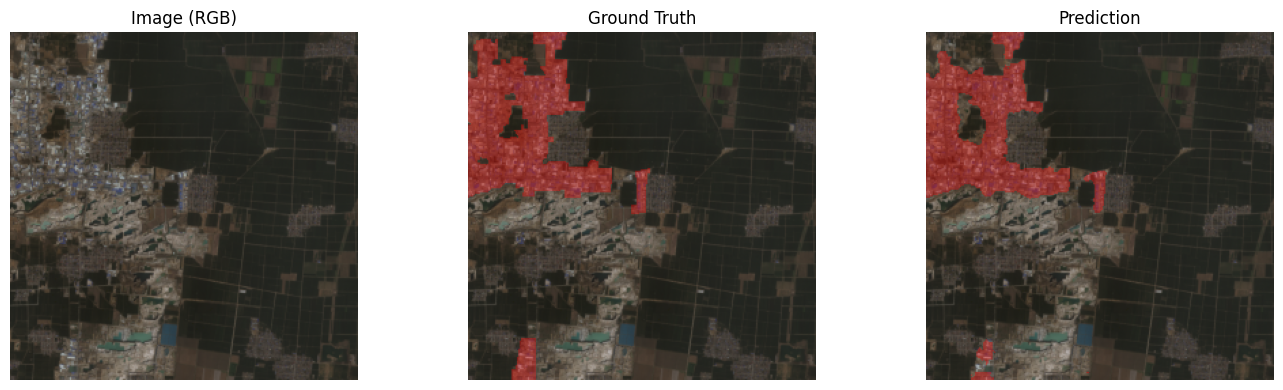

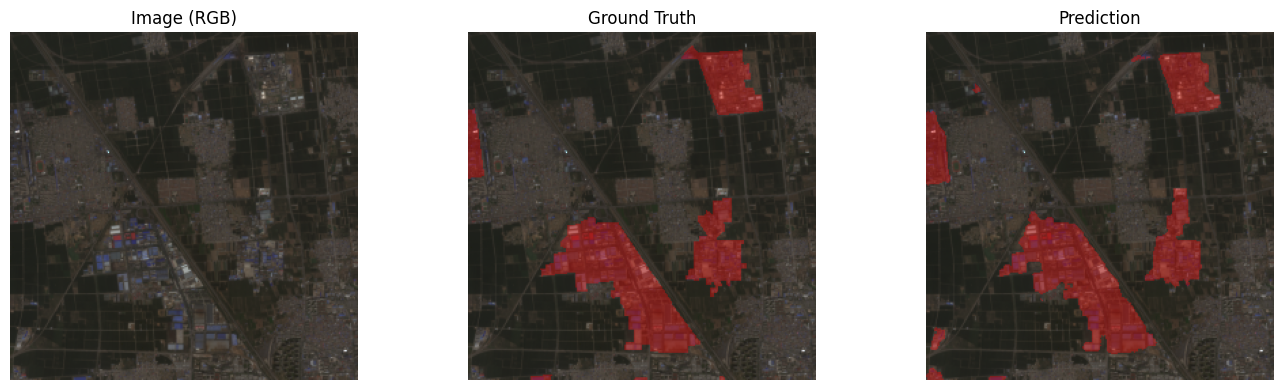

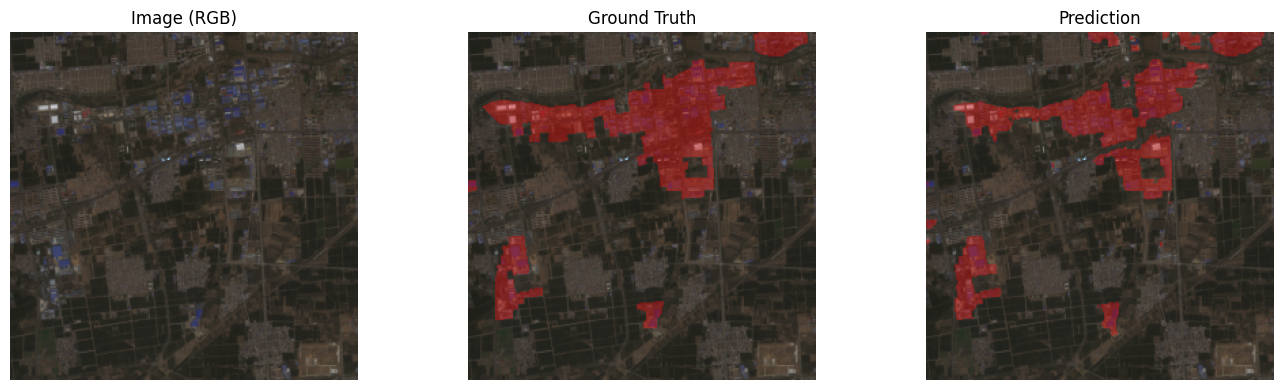

In [9]:
#@title 9. 최종 평가 및 샘플 시각화
# --- 1. 가장 성능이 좋았던 가중치로 다시 평가 ---
model.load_weights(CKPT_PATH)
res = model.evaluate(valid_ds, return_dict=True, verbose=1)

print("\n--- 최종 성능 지표 (mIoU) ---")
for k, v in res.items():
    print(f"  - {k:12s}: {float(v):.4f}")
print("--------------------")

# --- 2. 시각화 함수 ---
def overlay_red(img, mask01, alpha=0.35):
    red = np.zeros_like(img, dtype=np.float32); red[..., 0] = 1.0
    # ⚠️ 다중 채널 이미지(5채널)를 3채널(RGB)로 변환하여 시각화
    vis_img = img[..., :3] if img.shape[-1] >= 3 else np.repeat(img[..., :1], 3, axis=-1)
    vis_img = np.clip(vis_img, 0, 1)

    m3  = np.repeat(mask01[..., None], 3, axis=2).astype(np.float32)
    return vis_img*(1 - alpha*m3) + red*(alpha*m3)

def show_samples(ds, n=3):
    for imgs, masks in ds.take(1):
        preds = model.predict(imgs, verbose=0)
        gt = (masks.numpy()[..., 0] > 0.5).astype(np.uint8)
        pr = (preds[..., 0] > 0.5).astype(np.uint8)

        for i in range(min(n, imgs.shape[0])):
            vis = np.clip(imgs[i].numpy(), 0, 1)
            # ⚠️ 다중 채널 이미지(5채널)를 3채널(RGB)로 변환하여 시각화
            vis = vis[..., :3] if vis.shape[-1] >= 3 else np.repeat(vis[..., :1], 3, axis=-1)

            fig, ax = plt.subplots(1, 3, figsize=(14, 4))
            ax[0].imshow(vis); ax[0].set_title("Image (RGB)"); ax[0].axis("off")
            ax[1].imshow(overlay_red(vis, gt[i])); ax[1].set_title("Ground Truth"); ax[1].axis("off")
            ax[2].imshow(overlay_red(vis, pr[i])); ax[2].set_title("Prediction"); ax[2].axis("off")
            plt.tight_layout(); plt.show()

# --- 3. 샘플 시각화 실행 ---
print("\n--- 예측 결과 샘플 ---")
show_samples(valid_ds, n=3)